**Author: Trịnh Thái Gia Bảo**
## 1.Giới thiệu bài toán
Dự đoán kết quả thi cuối kỳ (final_exam_score hoặc course_result) dựa trên:
- attendance_rate
- avg_quiz_score
- assignment_completion_rate
- study_hours
- lms_logins

-> Đây là bài toán Supervised Learning

Input (X): các chỉ số học tập 

Output (y): final_exam_score (Linear Regression) hoặc course_result (Binary Classification)


## 2. Nạp dữ liệu

In [1]:
# %pip install pandas matplotlib
#%pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("lab1_student_learning_records.csv")
df.head()

,student_id,attendance_rate,avg_quiz_score,assignment_completion_rate,study_hours_per_week,lms_logins_per_week,final_exam_score,course_result
0,S001,0.802709,69.579350,0.759963,10.807935,8,64.8,pass
1,S002,0.793965,73.622387,0.821814,12.654235,12,82.2,pass
2,S003,0.849561,90.355132,0.787498,7.574707,11,69.9,pass
3,S004,0.924809,68.631185,0.847788,8.992854,12,72.7,pass
4,S005,0.505607,63.503530,0.615154,11.504049,12,55.6,pass


## 3. Kiểm tra dữ liệu

In [4]:
df.shape
df.info()
df.columns
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  180 non-null    object 
 1   attendance_rate             174 non-null    float64
 2   avg_quiz_score              177 non-null    float64
 3   assignment_completion_rate  180 non-null    float64
 4   study_hours_per_week        180 non-null    float64
 5   lms_logins_per_week         180 non-null    int64  
 6   final_exam_score            180 non-null    float64
 7   course_result               180 non-null    object 
dtypes: float64(5), int64(1), object(2)
memory usage: 11.4+ KB


student_id                    0
attendance_rate               6
avg_quiz_score                3
assignment_completion_rate    0
study_hours_per_week          0
lms_logins_per_week           0
final_exam_score              0
course_result                 0
dtype: int64

### Xác định biến
Input (X):
- attendance_rate
- avg_quiz_score
- assignment_completion_rate
- study_hours
- lms_logins

Target (y):
- final_exam_score (Regression)
- course_result (Classification)

## 4. Thống kê mô tả

In [9]:
feature_columns = [
'attendance_rate',
'avg_quiz_score',
'assignment_completion_rate',
'study_hours_per_week',
'lms_logins_per_week'
]

summary_stats = df[feature_columns].agg(['mean','median','std','min','max']).T

summary_stats

,mean,median,std,min,max
attendance_rate,0.824787,0.817548,0.110942,0.505607,1.000000
avg_quiz_score,72.091619,72.856552,14.069385,35.858009,100.000000
assignment_completion_rate,0.753877,0.776309,0.157857,0.350000,1.000000
study_hours_per_week,7.444630,7.568953,3.918410,0.000000,17.264685
lms_logins_per_week,9.033333,9.000000,3.935088,0.000000,24.000000


## 5.Trực Quan Hóa

Histogram
Attendance Rate: Phân phối lệch trái (skewed left). Đa số sinh viên có tỉ lệ đi học cao (tập trung từ 0.7 đến 1.0). Có một vài outliers (giá trị ngoại lai) ở mức thấp (dưới 0.6).
Avg Quiz Score: Phân phối khá giống hình chuông (Normal distribution), tập trung quanh mức 70-80 điểm. Điều này cho thấy đề kiểm tra có độ phân hóa tốt.
Assignment Completion Rate: Tương tự như chuyên cần, sinh viên có xu hướng hoàn thành bài tập khá tốt (tập trung vùng 0.7 - 0.9).
Study Hours per Week: Phân phối khá đều, trung bình khoảng 7-8 giờ/tuần. Tuy nhiên, dải giá trị rộng (từ 0 đến hơn 15 giờ) cho thấy sự khác biệt lớn trong nỗ lực cá nhân.
LMS Logins per Week: Phân phối chuẩn, trung bình khoảng 10 lần/tuần. Có một giá trị ngoại lai cực cao (hơn 20 lần) xuất hiện rõ trên Boxplot.


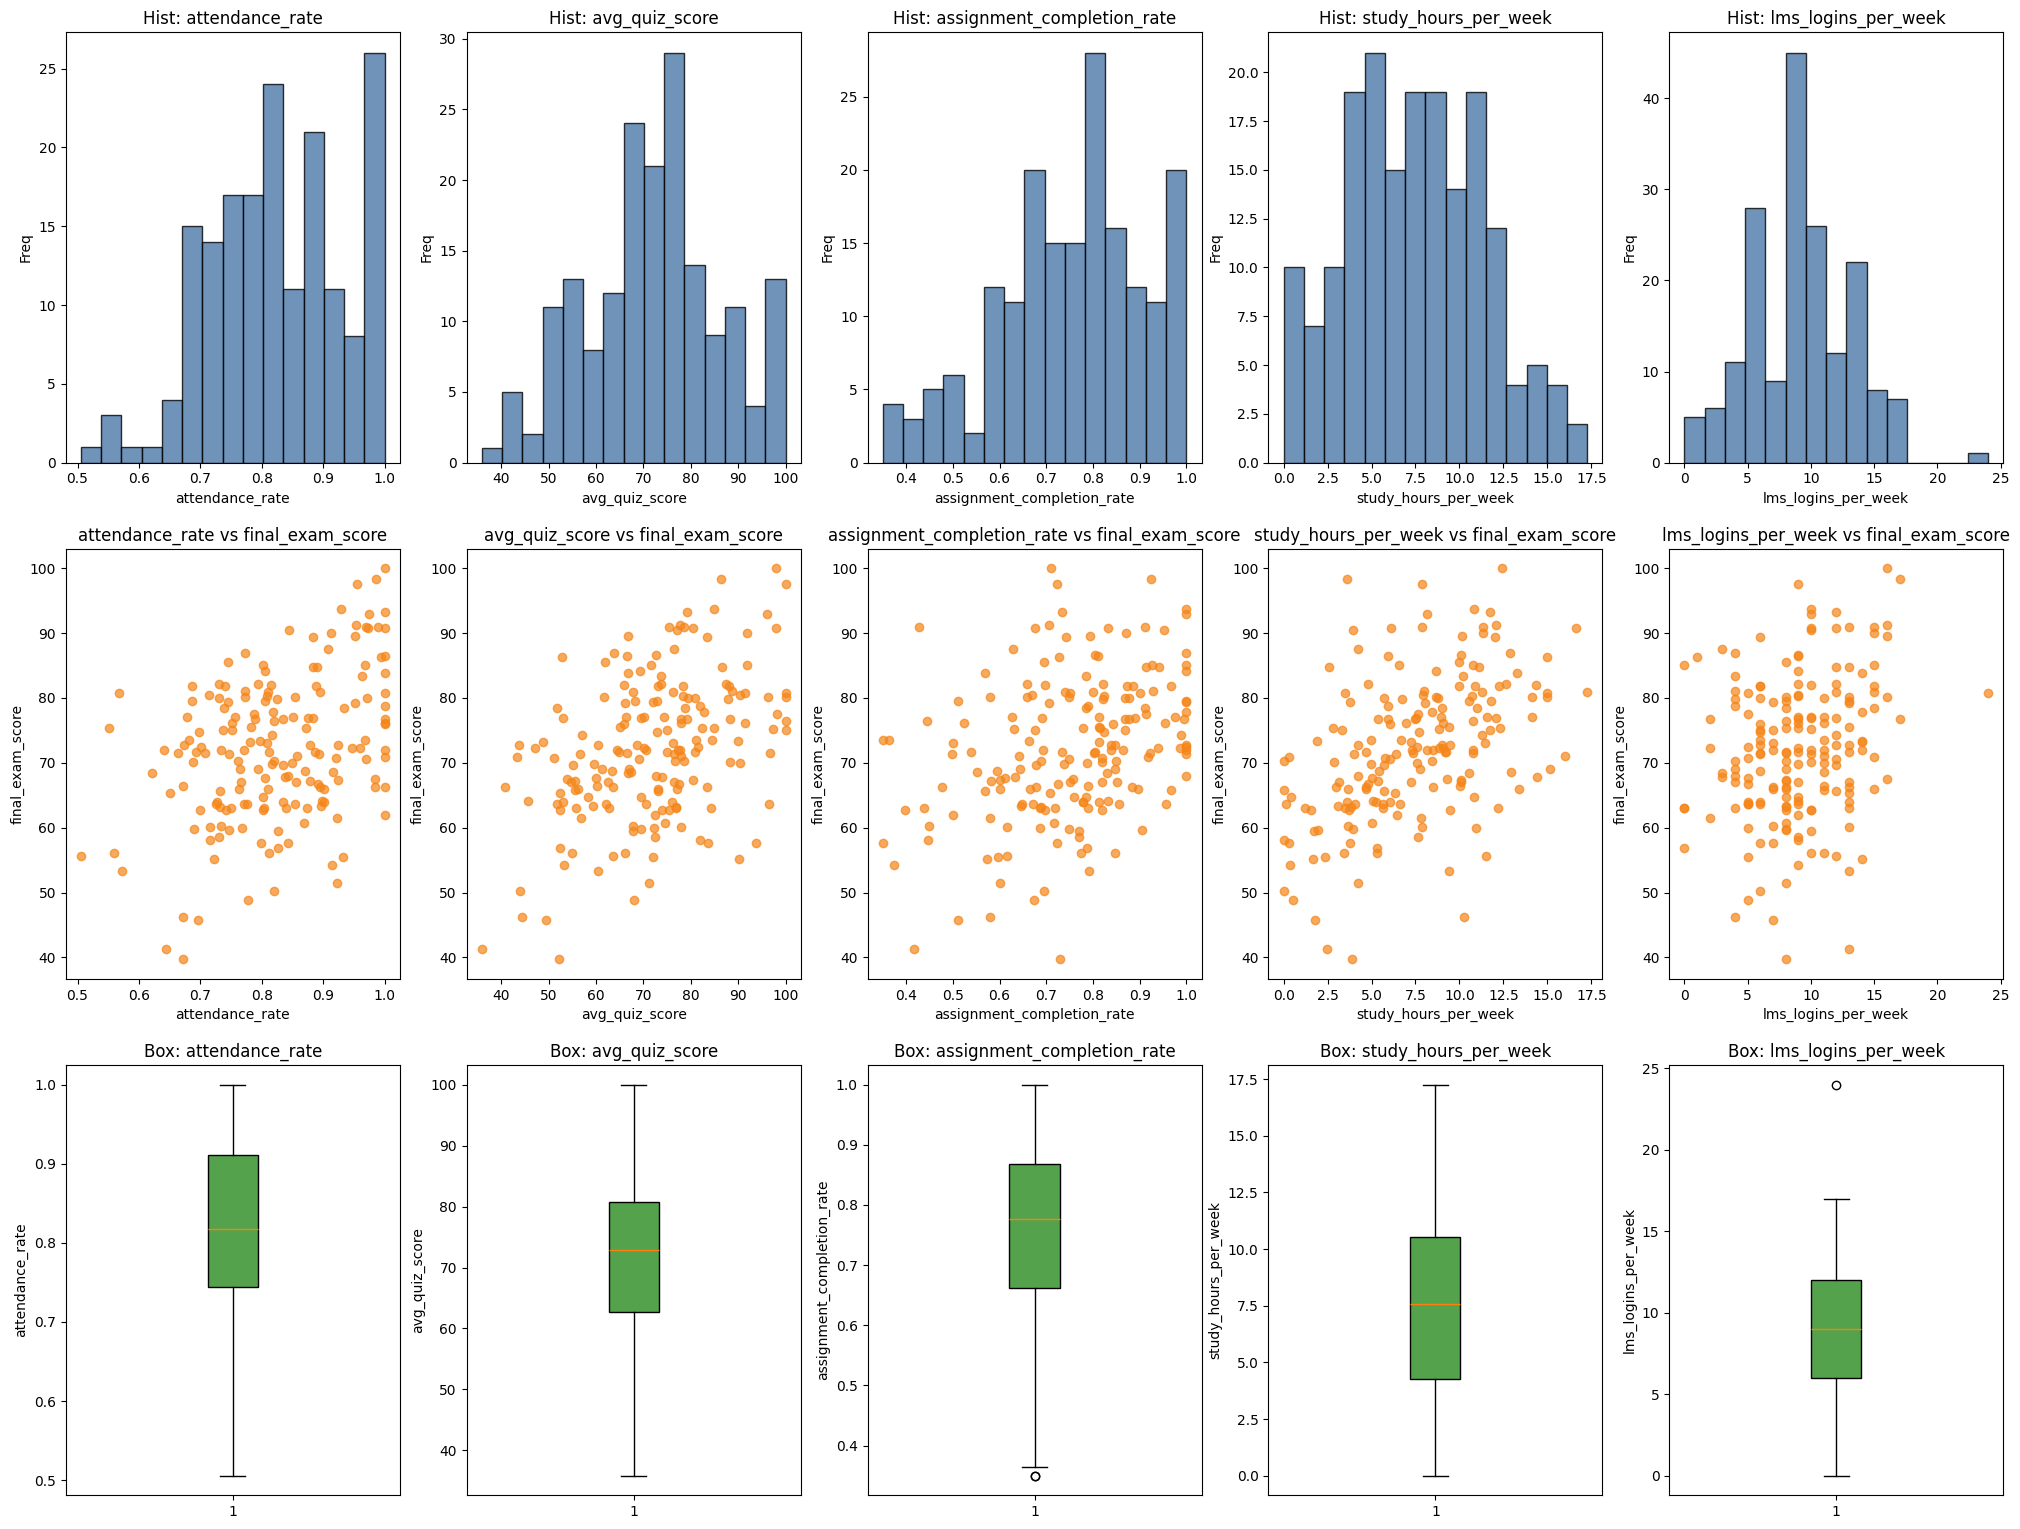

In [ ]:

feature_columns = [
    'attendance_rate',
    'avg_quiz_score',
    'assignment_completion_rate',
    'study_hours_per_week',
    'lms_logins_per_week' 
]

target = 'final_exam_score'


# =========================
# 1. FIGURE SETUP
# =========================
fig, axes = plt.subplots(3, len(feature_columns), figsize=(25, 19))


# =========================
# 2. HISTOGRAM (distribution)
# =========================
for ax, col in zip(axes[0], feature_columns):
    ax.hist(df[col].dropna(), bins=15,
            color='#4C78A8', edgecolor='black', alpha=0.8)
    ax.set_title(f'Hist: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Freq')


# =========================
# 3. SCATTER (relation vs target)
# =========================
for ax, col in zip(axes[1], feature_columns):
    ax.scatter(df[col], df[target],
               color='#F58518', alpha=0.7)
    ax.set_title(f'{col} vs {target}')
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    

# =========================
# 4. BOXPLOT (outliers)
# =========================
for ax, col in zip(axes[2], feature_columns):
    ax.boxplot(df[col].dropna(),
               patch_artist=True,
               boxprops=dict(facecolor='#54A24B'))
    ax.set_title(f'Box: {col}')
    ax.set_ylabel(col)



# =========================
# 5. CORRELATION HEATMAP
# (vẽ riêng vì không fit grid)
# =========================
# corr = df[feature_columns + [target]].corr()

# plt.figure(figsize=(6,5))
# plt.imshow(corr, cmap='coolwarm')
# plt.colorbar()
# plt.xticks(range(len(corr)), corr.columns, rotation=45)
# plt.yticks(range(len(corr)), corr.columns)
# plt.title("Correlation Matrix")
# plt.show()
print("Histogram")
print("Attendance Rate: Phân phối lệch trái (skewed left). Đa số sinh viên có tỉ lệ đi học cao (tập trung từ 0.7 đến 1.0). Có một vài outliers (giá trị ngoại lai) ở mức thấp (dưới 0.6).")
print("Avg Quiz Score: Phân phối khá giống hình chuông (Normal distribution), tập trung quanh mức 70-80 điểm. Điều này cho thấy đề kiểm tra có độ phân hóa tốt.")
print("Assignment Completion Rate: Tương tự như chuyên cần, sinh viên có xu hướng hoàn thành bài tập khá tốt (tập trung vùng 0.7 - 0.9).")
print("Study Hours per Week: Phân phối khá đều, trung bình khoảng 7-8 giờ/tuần. Tuy nhiên, dải giá trị rộng (từ 0 đến hơn 15 giờ) cho thấy sự khác biệt lớn trong nỗ lực cá nhân.")
print("LMS Logins per Week: Phân phối chuẩn, trung bình khoảng 10 lần/tuần. Có một giá trị ngoại lai cực cao (hơn 20 lần) xuất hiện rõ trên Boxplot.")

print("Scatter")
print("Tất cả các biểu đồ scatter đều cho thấy xu hướng tuyến tính thuận: Khi các chỉ số đầu vào tăng, final_exam_score có xu hướng tăng theo.")
print("Độ tập trung: Mối quan hệ giữa avg_quiz_score và study_hours_per_week với final_exam_score có vẻ tốt hơn khi so với lms_logins_per_week.")



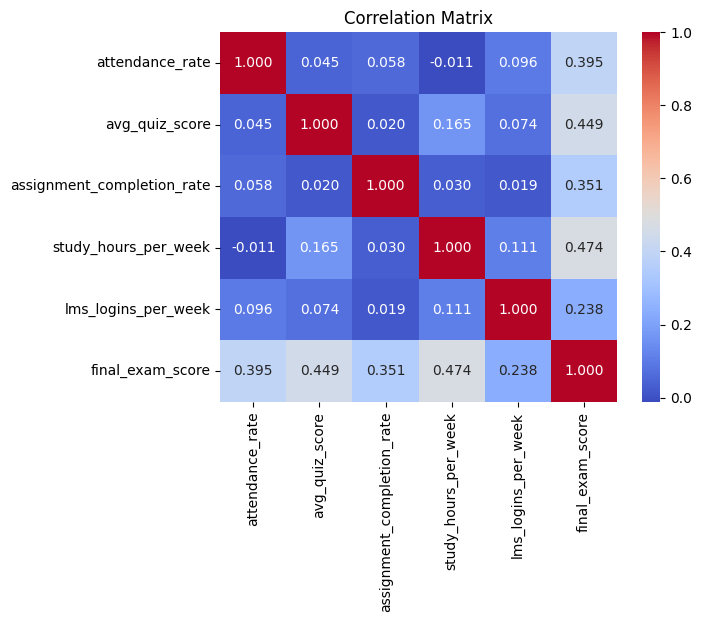

Study Hours per Week là yếu tố mạnh nhất. Thời gian tự học là yếu tố dự báo tốt nhất cho điểm số.
Avg Quiz Score mạnh thứ hai. Kết quả học tập quá trình phản ánh sát kết quả cuối kỳ.
Attendance Rate Trung bình khá. Đi học đầy đủ giúp cải thiện điểm số đáng kể.
Các features còn lại không ảnh hưởng tốt bằng các features trên


In [3]:
corr = df[feature_columns + [target]].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Correlation Matrix")
plt.show()


print("Study Hours per Week là yếu tố mạnh nhất. Thời gian tự học là yếu tố dự báo tốt nhất cho điểm số.")
print("Avg Quiz Score mạnh thứ hai. Kết quả học tập quá trình phản ánh sát kết quả cuối kỳ.")
print("Attendance Rate Trung bình khá. Đi học đầy đủ giúp cải thiện điểm số đáng kể.")
print("Các features còn lại không ảnh hưởng tốt bằng các features trên")

## 6.Nhận Xét
Yếu tố then chốt: Thời gian tự học (study_hours) và Phong độ quá trình (avg_quiz_score) là hai yếu tố quan trọng nhất, có tác động trực tiếp và mạnh mẽ nhất đến điểm thi cuối kỳ.

Chất lượng hơn số lượng: Việc "chăm chỉ" trên hệ thống (lms_logins) có sự tương quan thấp nhất; nghĩa là đăng nhập nhiều không quan trọng bằng việc thực sự ngồi học và làm bài.

Dữ liệu lý tưởng cho ML: Các biến độc lập ít bị trùng lặp thông tin (tương quan nội tại thấp), rất thuận lợi để xây dựng mô hình dự báo chính xác mà không lo bị nhiễu.

## 7.Machine Learning Pipeline
Raw Data (CSV)  
↓  
Data Cleaning (missing values, outliers)  
↓  
Feature Engineering  
↓  
Train/Test Split  
↓  
Model Training (Linear Regression / Logistic Regression)  
↓  
Evaluation (Accuracy / RMSE)  
↓  
Deployment / Report  